# 13_01 — Simulación y preprocesamiento · Escenario 3 (Algoritmo 3 del anexo)

Paso **1 de 3** del ciclo `Python → MATLAB → Python`:

| Paso | Archivo | Qué hace |
|---|---|---|
| 1 | **este notebook** | genera los datos, ajusta base + FPCA + estandarizador, escribe los datasets AR y todos los artefactos |
| 2 | `psbp_fd_iteracion.m` | muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento |
| 3 | `13_03_convergencia` / `13_04_evaluacion` | diagnóstico de cadenas y evaluación fuera de muestra |

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de
experimento. Todo lo demás se deriva de ellas.

## 1. Imports y rutas

In [1]:
1

1

In [ ]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenario3, generar_escenario_3, guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
from model_psbp_fd.utils import get_project_root
from model_psbp_fd.utils.quadrature import pesos_trapezoidales
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASENAME     = "escenario"
ESCENARIO_ID = 3      # Algoritmo k del anexo
REPLICA_ID   = 1      # réplica Monte Carlo; eje del barrido en la Etapa D
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")

PROJECT_ROOT  : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_ID : escenario_3_r01
Escenario 3 · réplica 1 · seed base 41232


In [3]:
# Las cinco rutas del contrato. No existe un config_paths en Python: cada
# notebook lo arma aquí y config_paths.m replica las mismas del lado MATLAB.
PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID,
}
for nombre, ruta in PATHS.items():
    ruta.mkdir(parents=True, exist_ok=True)
    print(f"  {nombre:12s} → {ruta}")

  raw          → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_3_r01
  functional   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_3_r01
  predict      → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_3_r01
  out_report   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_3_r01
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_3_r01


## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador

`L`, `T`, `PROP_TRAIN`, `burn_in`, `sigma_obs` y `mu` son los **parámetros
fijos del estudio**, idénticos a los de las corridas 11 y 12.

El resto son propiedades del Algoritmo 3 y provienen del Cuadro
`tab:ane_alg3`. Dos notas sobre ellos:

- **`hs_norms = (0.30, 0.80)`.** El default de `ConfigEscenario3` es `0.85` en
  el segundo régimen; el cuadro del anexo dice `0.80` y ésa es la decisión
  tomada. Se pasa explícito para que la corrida no dependa de cuál sea el
  default vigente del código.
- **`desplazamientos = (-1.5, +1.5)`.** El anexo los incorpora y argumenta por
  qué: si los regímenes difirieran sólo por su operador, la condicional sería
  una mezcla de dos gaussianas de **igual media**, unimodal y bien aproximada
  por una sola gaussiana de varianza intermedia; el escenario no distinguiría
  entonces un modelo capaz de representar mezclas de uno que no lo es. La
  forma `f` es constante para que el desplazamiento sea vertical y uniforme y
  no introduzca un segundo mecanismo de variación de forma.

`mecanismo = "probit"` es el escenario informativo: los pesos de la mezcla
dependen del estado rezagado. Los otros dos mecanismos disponibles —`"markov"`,
con pesos independientes del estado, y `"quiebre"`, no estacionario por
construcción— quedan fuera de esta corrida.

In [4]:
# ── Parámetros fijos del estudio (comunes a los 6 escenarios) ────────────────
L_GRILLA   = 75     # puntos de la grilla regular tau_1=0 … tau_L=1
T_CURVAS   = 400    # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.25   # desviación del ruido de medición

def media_senoidal(tau):
    """mu(tau) = sin(2 pi tau), Cuadro tab:ane_esquema. Con nombre para que
    quede legible en el JSON."""
    return np.sin(2.0 * np.pi * tau)

SIM_CFG = ConfigEscenario3(
    # Esquema de observación
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 200,
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = media_senoidal,
    # Operadores por régimen (Cuadro tab:ane_alg3)
    gammas     = (0.30, 0.30),
    hs_norms   = (0.30, 0.80),   # ← 0.80 por decisión; el default del código es 0.85
    sigmas_eps = (1.0, 1.0),
    # Desplazamiento de nivel: lo que hace la condicional BIMODAL
    desplazamientos         = (-1.5, 1.5),
    forma_desplazamiento_fn = None,   # None ⇒ f constante
    # Innovación funcional
    ell = 0.2,
    # Mecanismo de transición dependiente del estado
    mecanismo    = "probit",
    umbrales     = (0.0,),
    nitidez      = 2.0,
    direccion_fn = None,   # None ⇒ e constante, normalizada en L^2
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<24}: {v}")

  L                       : 75
  T                       : 400
  burn_in                 : 200
  sigma_obs               : 0.25
  R                       : 1
  seed                    : 41232
  media_fn                : media_senoidal
  jitter                  : 1e-10
  gammas                  : (0.3, 0.3)
  hs_norms                : (0.3, 0.8)
  sigmas_eps              : (1.0, 1.0)
  desplazamientos         : (-1.5, 1.5)
  forma_desplazamiento_fn : None
  ell                     : 0.2
  mecanismo               : probit
  umbrales                : (0.0,)
  nitidez                 : 2.0
  direccion_fn            : None
  matriz_transicion       : None
  fracciones_quiebre      : (0.5,)


### 2.2 Generación

In [5]:
salida = generar_escenario_3(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw   = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA — alimenta la estimación
X_true  = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — objetivo de evaluación
REGIMEN = salida.internos["regimenes"][REPLICA_IDX]   # (T,) base-0, estado LATENTE
grilla  = salida.grilla
T, G    = X_raw.shape
J       = SIM_CFG.n_regimenes

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print(f"regímenes {REGIMEN.shape} · valores {np.unique(REGIMEN)} (base-0)")
print("\nControl de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:36s} = {v}")

Observadas (400, 75) · verdaderas (400, 75) · grilla (75,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2503   (nominal 0.25)
regímenes (400,) · valores [0 1] (base-0)

Control de calidad del generador:
  n_replicas                           = 1
  n_curvas                             = 400
  n_puntos_grilla                      = 75
  todo_finito                          = True
  media_empirica_global                = 0.7246353457149871
  media_ee_montecarlo                  = nan
  var_puntual_media                    = 4.137256529685428
  var_puntual_min                      = 3.447338131928056
  var_puntual_max                      = 4.678324456901485
  acf1_media                           = 0.47985385796534796
  acf1_ee_montecarlo                   = nan
  razon_senal_ruido                    = 66.19610447496684
  mecanismo                            = probit
  n_regimenes                          = 2
  hs_norm_objetivo                     = [0.3, 0.8]
  hs_norm_efectiva     

#### Lectura del control de calidad

Las cifras que deciden si el escenario tiene contenido —el análogo de
`cv(sigma^2)` y la ACF de los residuos al cuadrado en la corrida 12— son:

- **`separacion_en_sd_puntual`**: cuánto separa el desplazamiento de nivel a
  los dos regímenes, medido en desviaciones estándar puntuales del proceso. Si
  fuera pequeña la mezcla sería unimodal y el escenario no probaría nada.
- **`proporcion_regimen_minima`**: que ningún régimen quede casi vacío. Con un
  régimen presente en menos del 15 % de los períodos, el bloque de prueba puede
  no contener suficientes orígenes de ese régimen para estratificar la
  cobertura en `13_04 §9`.
- **`duracion_media_racha`**: cuánto dura en promedio una permanencia. Rachas
  muy cortas producen una serie que alterna casi en cada período; muy largas la
  acercan a un cambio estructural.
- **`contractividad_todos_los_regimenes`** y `estacionariedad_garantizada`: la
  condición suficiente de ergodicidad geométrica que el anexo exige.

In [6]:
_d = salida.diagnostico
_chequeos = [
    ("contractividad de todos los regímenes", _d["contractividad_todos_los_regimenes"],
     f"max ||Psi_j||_HS = {_d['hs_norm_maxima']:.4f}"),
    ("estacionariedad garantizada",           _d["estacionariedad_garantizada"],
     f"mecanismo = {_d['mecanismo']}"),
    ("calibración de las normas HS",          _d["hs_norm_error_absoluto_max"] < 1e-8,
     f"objetivo {_d['hs_norm_objetivo']} · efectiva "
     f"{[round(h, 4) for h in _d['hs_norm_efectiva']]}"),
    ("ambos regímenes presentes",             _d["proporcion_regimen_minima"] > 0.15,
     f"proporciones {[round(p, 3) for p in _d['proporcion_regimen']]}"),
    ("bimodalidad resoluble",                 _d["separacion_en_sd_puntual"] > 1.0,
     f"separación = {_d['separacion_en_sd_puntual']:.3f} sd puntuales"),
    ("rachas de duración razonable",          _d["duracion_media_racha"] > 1.5,
     f"duración media {_d['duracion_media_racha']:.2f} períodos "
     f"({_d['n_transiciones_media']:.0f} transiciones)"),
]
for nombre, ok, detalle in _chequeos:
    print(f"  {'✓' if ok else '✗'}  {nombre:38s} {detalle}")

assert all(ok for _, ok, _ in _chequeos[:3]), \
    "El generador no cumple las condiciones estructurales del Algoritmo 3."
if not all(ok for _, ok, _ in _chequeos[3:]):
    print("\n⚠ El mecanismo de cambio de régimen no se manifiesta con claridad: "
          "revisar\n  `desplazamientos`, `nitidez` o `umbrales` antes de gastar "
          "el MCMC.")

  ✓  contractividad de todos los regímenes  max ||Psi_j||_HS = 0.8000
  ✓  estacionariedad garantizada            mecanismo = probit
  ✓  calibración de las normas HS           objetivo [0.3, 0.8] · efectiva [0.3, 0.8]
  ✓  ambos regímenes presentes              proporciones [0.352, 0.647]
  ✓  bimodalidad resoluble                  separación = 1.475 sd puntuales
  ✓  rachas de duración razonable           duración media 2.86 períodos (139 transiciones)


### 2.3 Reconstrucción del mecanismo latente

Para poder estratificar y para elegir los orígenes *ambiguos* de `13_04 §9.1`
hace falta, además del régimen vigente, la **probabilidad** con que se sorteó:

$$z_{t-1}=\langle X_{t-1}-\mu-d_{R_{t-1}}f,\;e\rangle_{L^2},
\qquad p_t=\Phi\bigl(\kappa(c-z_{t-1})\bigr).$$

La proyección se calcula sobre el estado autorregresivo $Y_{t-1}$ —la curva
verdadera menos la media **y menos el desplazamiento de su propio régimen**—,
que es exactamente lo que el generador proyecta. Restar sólo $\mu$ mezclaría
el desplazamiento con el estado y daría una $p_t$ que no es la que se usó.

Todo esto se calcula aquí, donde `internos` está disponible, y se persiste.
Ninguna de estas cantidades entra en la estimación.

In [7]:
direccion = salida.internos["direccion_estado"]      # (G,) e(tau), norma L2 unitaria
despl     = salida.internos["desplazamientos"]       # (J, G) d_j f(tau)
mu_true   = salida.media                             # (G,)
w_quad    = pesos_trapezoidales(grilla)

# Estado autorregresivo Y_t = X_t - mu - d_{R_t}
Y_estado = X_true - mu_true[None, :] - despl[REGIMEN]        # (T, G)
z_proj   = (Y_estado * direccion[None, :]) @ w_quad          # (T,) <Y_t, e>

# p_t depende de z_{t-1}: el primer período retenido usa el último del burn-in,
# que no se conserva, de modo que su p queda indefinida (NaN) y se excluye.
from scipy.stats import norm as _norm
UMBRAL, NITIDEZ = SIM_CFG.umbrales[0], SIM_CFG.nitidez
p_reg1        = np.full(T, np.nan)
p_reg1[1:]    = _norm.cdf(NITIDEZ * (UMBRAL - z_proj[:-1]))  # P(R_t = 1 | X_{t-1})
ambiguedad    = 0.5 - np.abs(p_reg1 - 0.5)                   # 0 = determinista, .5 = máxima

# Verificación: el régimen observado debe ser coherente con la probabilidad que
# lo generó. No es determinista —es un sorteo— pero la asociación debe ser fuerte.
_ok = ~np.isnan(p_reg1)
_tasa1 = (REGIMEN[_ok] == 0).mean()
_pred  = (p_reg1[_ok] > 0.5)
_acuerdo = ((REGIMEN[_ok] == 0) == _pred).mean()
print(f"P(R=1) media reconstruida = {p_reg1[_ok].mean():.3f}   "
      f"frecuencia empírica de R=1 = {_tasa1:.3f}")
print(f"acuerdo entre el régimen sorteado y argmax p_t: {_acuerdo:.3f}")
assert abs(p_reg1[_ok].mean() - _tasa1) < 0.10, (
    "La probabilidad reconstruida no coincide con la frecuencia observada: "
    "revisar el centrado de Y (¿se restó el desplazamiento del régimen?).")
print(f"\norígenes ambiguos (|p - 0.5| < 0.1): "
      f"{int((ambiguedad > 0.4).sum())} de {T}")

P(R=1) media reconstruida = 0.378   frecuencia empírica de R=1 = 0.353
acuerdo entre el régimen sorteado y argmax p_t: 0.832

orígenes ambiguos (|p - 0.5| < 0.1): 56 de 400


In [8]:
# Configuración de simulación + escenario completo en .npz
simulation_config = {
    "sim_params":    salida.config.to_dict(),
    "diagnostico":   salida.diagnostico,
    "replica_idx":   REPLICA_IDX,
    "experiment_id": EXPERIMENT_ID,
    "escenario_id":  int(ESCENARIO_ID),
    "replica_id":    int(REPLICA_ID),
    "seed":          SEED,
    "T": int(T), "G": int(G), "n_regimenes": int(J),
}
with open(PATHS["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
    json.dump(simulation_config, f, indent=2, ensure_ascii=False)

# incluir_internos=True guarda `interno_regimenes`, el estado verdadero contra
# el cual 13_04 estratifica la cobertura, además de los operadores y la
# dirección de proyección. Sin ello el eje 2 del diseño no se puede evaluar.
_npz = guardar_escenario(salida, str(PATHS["raw"] / f"escenario_{ESCENARIO_ID}"),
                         incluir_curvas=True, incluir_internos=True)
print(f"[raw] simulation_config.json  ·  {_npz}")

[raw] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_3_r01\escenario_3.npz


### 2.4 Visualización de los datos

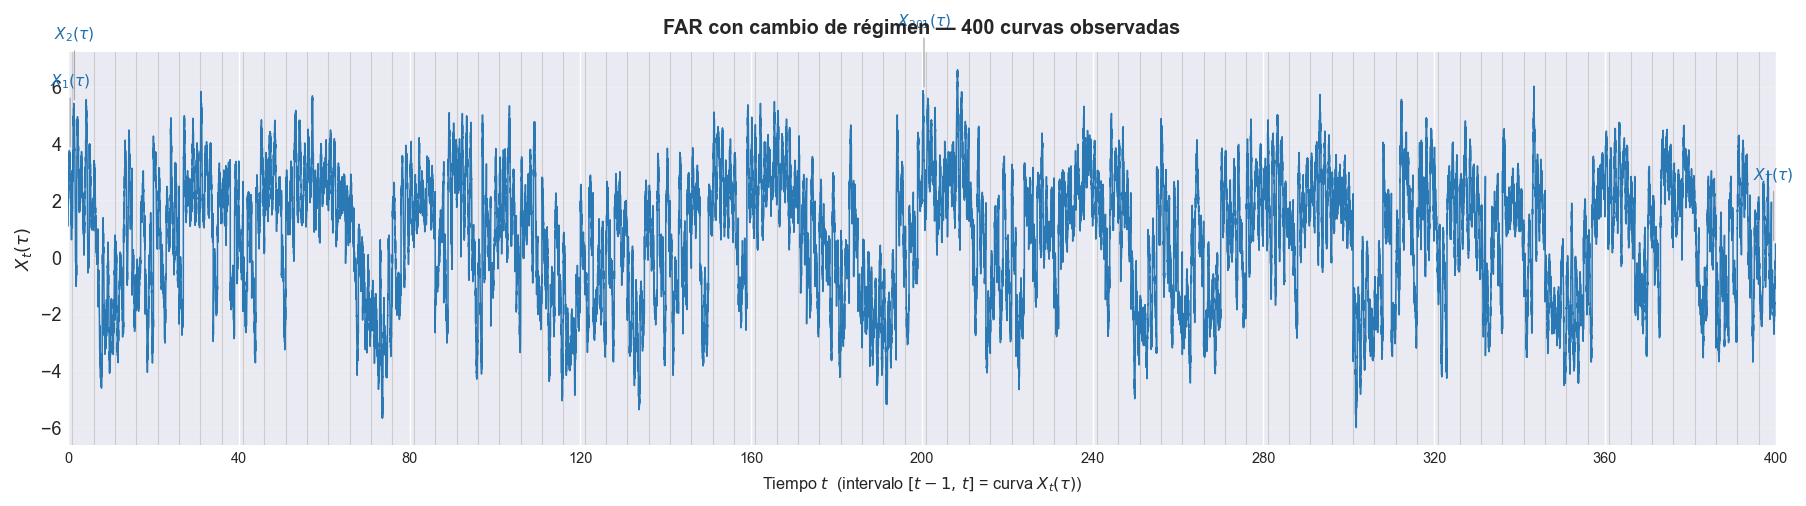

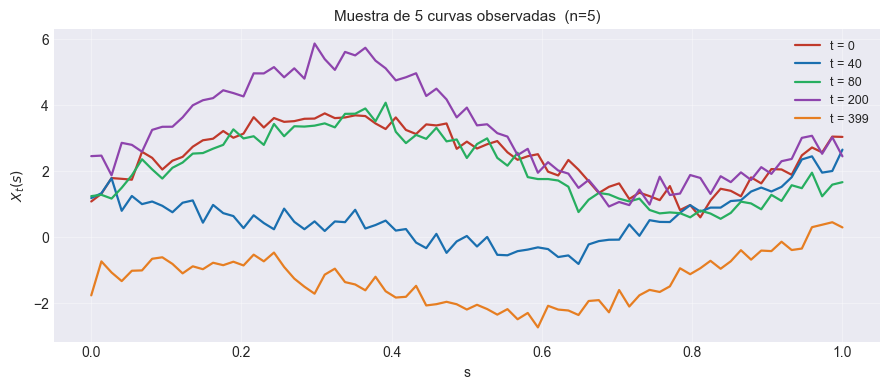

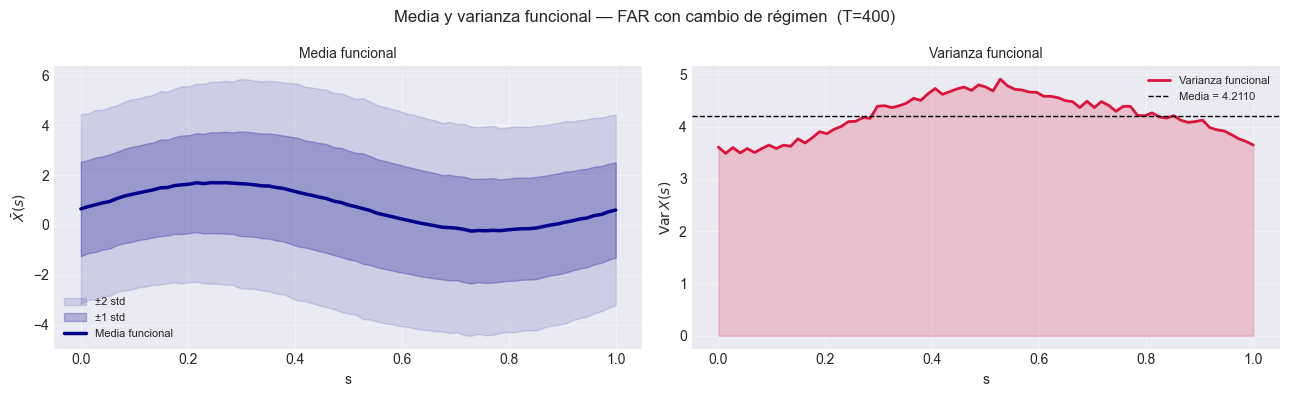

In [9]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR con cambio de régimen — {T} curvas observadas",
    save_path=str(PATHS["out_report"] / "01_fts_empirica_raw.png"))
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas",
    save_path=str(PATHS["out_report"] / "02_muestra_empirica_raw.png"))
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — FAR con cambio de régimen",
    save_path=str(PATHS["out_report"] / "03_media_varianza_raw.png"))
plt.show()

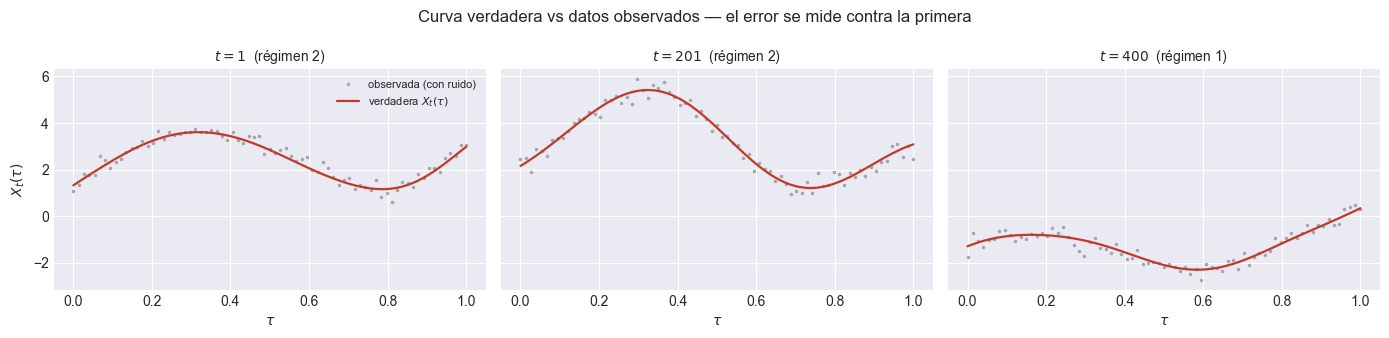

In [10]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$  (régimen {REGIMEN[i]+1})", fontsize=10)
    ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "04_curva_vs_datos.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.5 El rasgo del escenario: los dos regímenes

Figura propia del Algoritmo 3, sin equivalente en las corridas 11 y 12. Muestra
la cantidad que hace distinto a este escenario: la alternancia de regímenes, la
**bimodalidad** que induce en la distribución marginal del nivel de la curva, y
la relación entre el régimen sorteado y la proyección $z_{t-1}$ que lo gobierna.

El panel inferior derecho es el que anticipa el resultado de `13_04 §9.1`: si
las dos modas están bien separadas en la **marginal**, la condicional dada un
origen ambiguo también lo estará, y ahí es donde un modelo unimodal no puede
seguir.

`REGIMEN` es **latente**: no entra en la base, ni en el FPCA, ni en el
estandarizador, ni en ningún predictor.

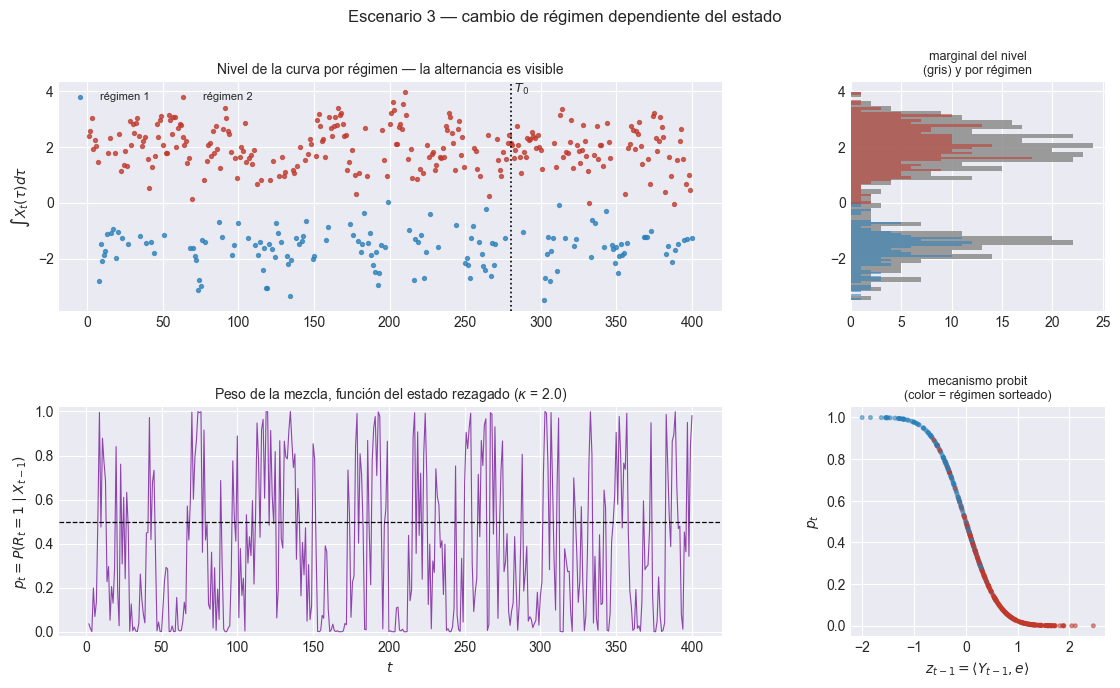

nivel medio por régimen : [-1.628, 2.008]
separación de niveles   : 3.636   (sd dentro de régimen ≈ 0.709)
proporciones            : [0.352, 0.647]


In [11]:
nivel = (X_true * w_quad).sum(axis=1)      # <X_t, 1>: nivel medio de la curva
colores = ["#2980b9", "#c0392b"]

fig = plt.figure(figsize=(13.5, 7.2))
gs  = fig.add_gridspec(2, 2, width_ratios=[3, 1.15], hspace=0.42, wspace=0.28)

# (a) nivel de la curva coloreado por régimen
ax = fig.add_subplot(gs[0, 0])
for j in range(J):
    m = REGIMEN == j
    ax.scatter(np.arange(1, T + 1)[m], nivel[m], s=8, alpha=0.75,
               color=colores[j], label=f"régimen {j+1}")
T0_prev = int(np.floor(PROP_TRAIN * T))
ax.axvline(T0_prev, color="k", ls=":", lw=1.2)
ax.text(T0_prev, ax.get_ylim()[1], " $T_0$", fontsize=9, va="top")
ax.set_ylabel(r"$\int X_t(\tau)d\tau$"); ax.legend(fontsize=8, ncol=2)
ax.set_title("Nivel de la curva por régimen — la alternancia es visible",
             fontsize=10)

# (b) marginal del nivel: ¿es bimodal?
ax = fig.add_subplot(gs[0, 1])
ax.hist(nivel, bins=45, color="0.55", alpha=0.85, orientation="horizontal",
        label="marginal")
for j in range(J):
    ax.hist(nivel[REGIMEN == j], bins=45, alpha=0.55, color=colores[j],
            orientation="horizontal")
ax.set_title("marginal del nivel\n(gris) y por régimen", fontsize=9)

# (c) probabilidad de régimen 1 a lo largo del tiempo
ax = fig.add_subplot(gs[1, 0])
ax.plot(np.arange(1, T + 1), p_reg1, lw=0.8, color="#8e44ad")
ax.axhline(0.5, color="k", ls="--", lw=0.9)
ax.set_xlabel("$t$"); ax.set_ylabel(r"$p_t=P(R_t=1\mid X_{t-1})$")
ax.set_ylim(-0.02, 1.02)
ax.set_title(r"Peso de la mezcla, función del estado rezagado "
             r"($\kappa$ = " f"{NITIDEZ}" r")", fontsize=10)

# (d) el mecanismo: régimen sorteado vs proyección que lo gobierna
ax = fig.add_subplot(gs[1, 1])
_o = ~np.isnan(p_reg1)
ax.scatter(z_proj[:-1][_o[1:]], p_reg1[1:][_o[1:]], s=7, alpha=0.5,
           c=[colores[j] for j in REGIMEN[1:][_o[1:]]])
ax.set_xlabel(r"$z_{t-1}=\langle Y_{t-1},e\rangle$")
ax.set_ylabel(r"$p_t$")
ax.set_title("mecanismo probit\n(color = régimen sorteado)", fontsize=9)

fig.suptitle("Escenario 3 — cambio de régimen dependiente del estado", fontsize=12)
fig.savefig(PATHS["out_report"] / "10_regimenes.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"nivel medio por régimen : "
      f"{[round(float(nivel[REGIMEN==j].mean()), 3) for j in range(J)]}")
print(f"separación de niveles   : "
      f"{abs(nivel[REGIMEN==1].mean() - nivel[REGIMEN==0].mean()):.3f}   "
      f"(sd dentro de régimen ≈ "
      f"{np.mean([nivel[REGIMEN==j].std() for j in range(J)]):.3f})")
print(f"proporciones            : "
      f"{[round(float((REGIMEN==j).mean()), 3) for j in range(J)]}")

#### Persistencia del estado verdadero

Se guarda como CSV —y no sólo dentro del `.npz`— porque es el insumo del eje 2
de la evaluación y conviene que sea legible y versionable sin abrir un binario.
`13_04` lo lee de aquí; su nombre queda declarado en `eval_config.json`.

In [12]:
estado_df = pd.DataFrame({
    "t":            np.arange(1, T + 1),
    "regimen":      REGIMEN + 1,        # base-1, para leer la tabla
    "regimen_idx":  REGIMEN,            # base-0, el que consume cobertura_condicional
    "p_regimen1":   p_reg1,             # P(R_t = 1 | X_{t-1}); NaN en t = 1
    "ambiguedad":   ambiguedad,         # 0.5 - |p - 0.5|
    "z_lag":        np.concatenate([[np.nan], z_proj[:-1]]),
    "nivel_curva":  nivel,
})
estado_df.to_csv(PATHS["out_report"] / "10_estado_regimen.csv", index=False)
print(f"[out_report] 10_estado_regimen.csv  {estado_df.shape}")
display(estado_df.head())

[out_report] 10_estado_regimen.csv  (400, 7)


,t,regimen,regimen_idx,p_regimen1,ambiguedad,z_lag,nivel_curva
0,1,2,1,NaN,NaN,NaN,2.396690
1,2,2,1,0.036456,0.036456,0.896690,2.576719
2,3,2,1,0.015642,0.015642,1.076719,3.043511
3,4,2,1,0.001011,0.001011,1.543511,1.922783
4,5,2,1,0.198898,0.198898,0.422783,2.239668


### 2.6 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [13]:
_p = guardar_curvas(PATHS, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} → {ruta.name}")

[functional] curvas       → X_curves.npy
[functional] grilla       → domain_grid.npy
[functional] curvas_true  → X_curves_true.npy


### 2.7 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [14]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

# Aviso propio de este escenario: la estratificación de 13_04 §9 necesita
# suficientes orígenes de CADA régimen dentro del bloque de prueba.
_prop_tr = np.array([(REGIMEN[idx_train] == j).mean() for j in range(J)])
_prop_te = np.array([(REGIMEN[idx_test]  == j).mean() for j in range(J)])
_n_te    = np.array([int((REGIMEN[idx_test] == j).sum()) for j in range(J)])
print(f"\nproporción de regímenes  train={np.round(_prop_tr,3)}  "
      f"test={np.round(_prop_te,3)}")
print(f"orígenes de prueba por régimen: {_n_te.tolist()}")
if _n_te.min() < 15:
    print("⚠ Un régimen tiene menos de 15 orígenes de prueba: su cobertura "
          "condicional\n  tendrá error de muestreo grande. Considerar otra "
          "semilla o reportar con reservas.")
if np.max(np.abs(_prop_te - _prop_tr)) > 0.15:
    print("⚠ La mezcla de regímenes cambia entre bloques: al leer 13_04, "
          "separar ese\n  efecto del de generalización usando la "
          "estratificación por régimen (§9).")

entrenamiento : t ∈ [1, 280]      → (280, 75)
prueba        : t ∈ [281, 400]  → (120, 75)
proporción    : 70.0% / 30.0%

proporción de regímenes  train=[0.361 0.639]  test=[0.333 0.667]
orígenes de prueba por régimen: [40, 80]


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,86.1375%,0.734743,1.615607,0.631298
1,3,2,91.0764%,0.583706,1.184840,0.417748
2,4,2,96.8641%,0.358146,0.680797,0.150970
3,5,2,98.0234%,0.289486,0.463315,0.097895
4,6,2,98.3983%,0.261506,0.390296,0.081645
5,7,2,98.5518%,0.249012,0.326487,0.076006
6,8,2,98.6320%,0.242048,0.313976,0.073957
7,9,2,98.6741%,0.238283,0.308969,0.073867
8,10,2,98.7069%,0.235287,0.307030,0.074276
9,11,2,98.7381%,0.232483,0.301466,0.074763



GCV mínimo → n_basis=8, order=3  (var retenida 98.6663%)


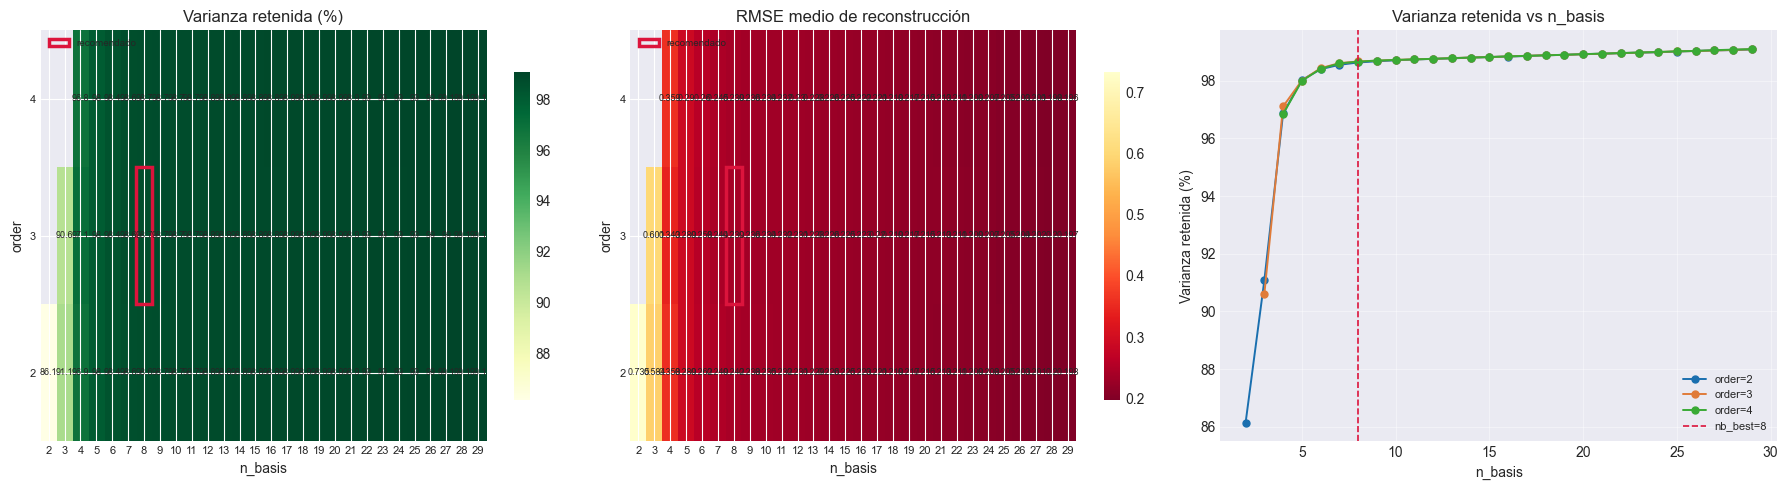

In [15]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best,
                     save_path=str(PATHS["out_report"] / "05_seleccion_basis.png"))
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Se conserva la misma base que las corridas 11 y 12 (`n_basis=8`, `order=3`)
salvo que el GCV lo desaconseje con claridad.

Base elegida : n_basis=8, order=3
Sugerido GCV : n_basis=8, order=3   (coinciden)
THETA (400, 8)  (train=280, test=120)


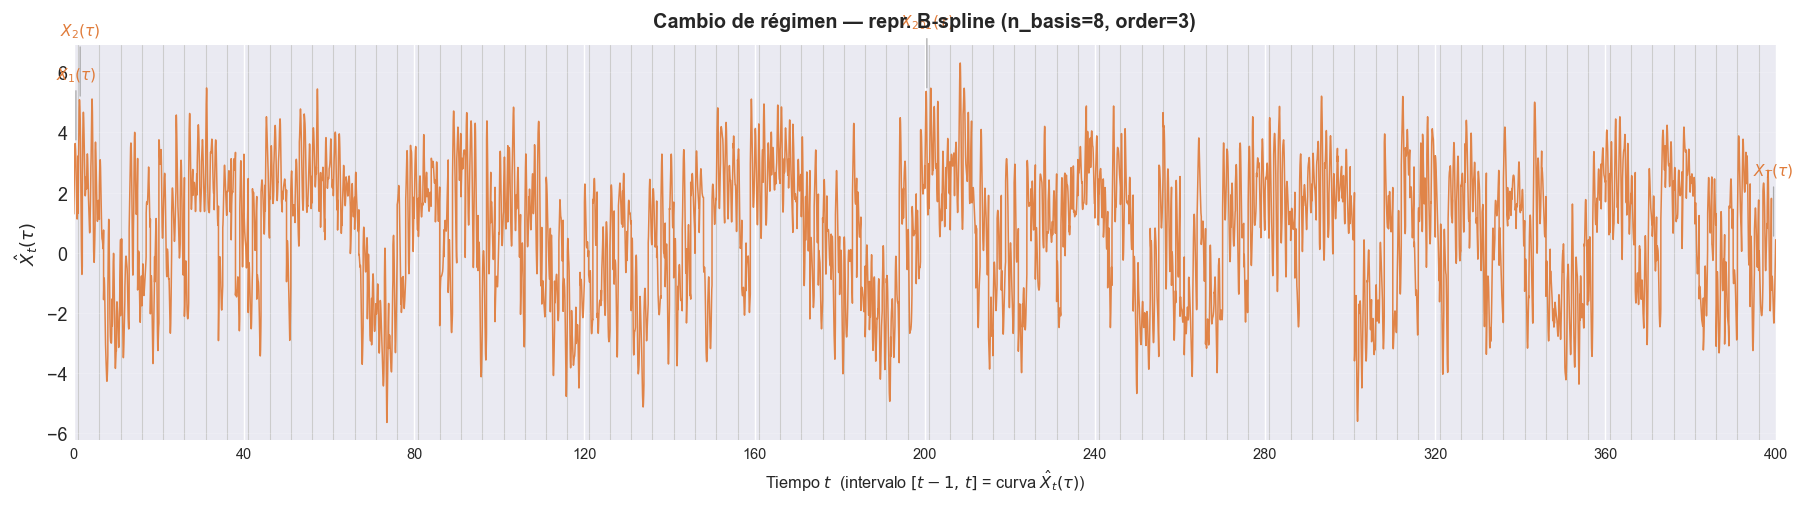

[functional] functional_representation.pkl + theta.csv + fr_config.json


In [16]:
NB_ELEGIDO  = 8     # ← decisión del analista
ORD_ELEGIDO = 3

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"Cambio de régimen — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})",
    save_path=str(PATHS["out_report"] / "06_fts_funcional_bspline.png"))
plt.show()

guardar_representacion(PATHS, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print("[functional] functional_representation.pkl + theta.csv + fr_config.json")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

La base B-spline no es ortonormal, de modo que la Gram $W\neq I$ y la
descomposición correcta resuelve el problema propio generalizado
$(W^{1/2}S_\theta W^{1/2})z=\lambda z$. Se ajusta **sólo con entrenamiento**.

In [17]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 8
  K                                  = 8
  n_ajuste                           = 280
  cond_W                             = 1.027e+01
  err_ortonormalidad_L2              = 2.220e-15
  err_ortonormalidad_gram            = 2.665e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 2.645e-16
  err_media_scores_rel               = 3.110e-15
  err_var_scores_vs_lambda           = 3.553e-15
  err_var_scores_vs_lambda_rel       = 8.034e-14
  err_correlacion_lag0               = 3.110e-14
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok      

,componente,autovalor,var_ratio,var_acum,ar1_propio,sep_regimen
0,1,3.7073e+00,86.6126%,86.6126%,+0.536,1.923
1,2,2.7924e-01,6.5239%,93.1364%,+0.142,0.036
2,3,1.9793e-01,4.6243%,97.7607%,+0.194,0.176
3,4,6.3310e-02,1.4791%,99.2398%,-0.138,0.006
4,5,2.3495e-02,0.5489%,99.7887%,+0.057,0.211
5,6,5.5633e-03,0.1300%,99.9187%,-0.016,0.056
6,7,2.4617e-03,0.0575%,99.9762%,-0.060,0.205
7,8,1.0175e-03,0.0238%,100.0000%,+0.016,0.032



K disponibles: 8   ·   sugerencia (var ≥ 95%): M = 3
componente que más separa los regímenes: FPC 1 (separación 1.923 sd)
   ← es la que debería mostrar predictiva bimodal en 13_04 §9.1


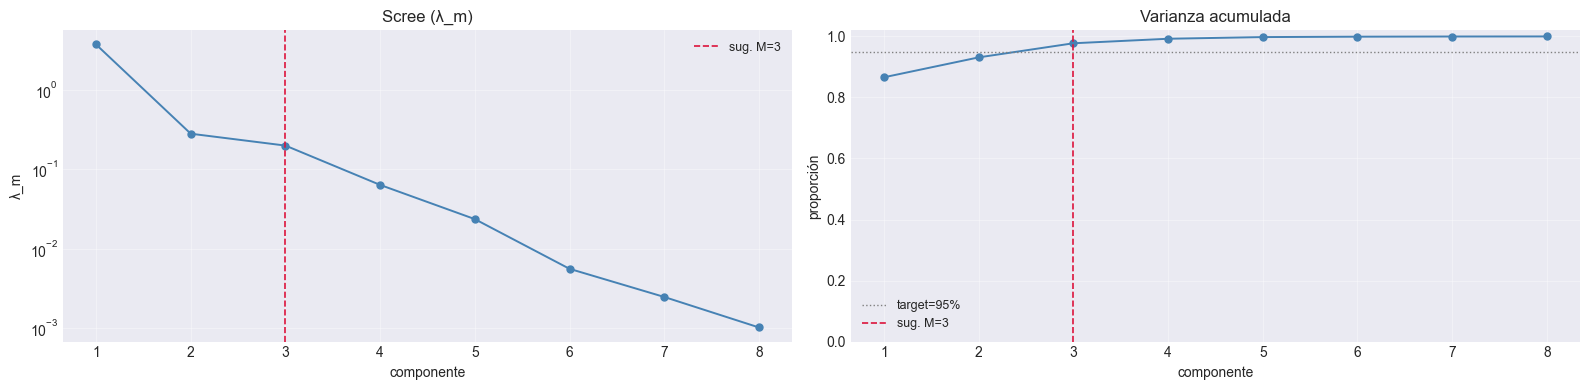

In [18]:
# Varianza ≠ dinámica. En este escenario se agrega una tercera columna propia:
# `sep_regimen`, la diferencia de medias del score entre los dos regímenes
# expresada en desviaciones estándar. Dice QUÉ componente carga el
# desplazamiento de nivel, y por tanto cuál de ellas debería mostrar una
# predictiva bimodal en 13_04 §9.1. Con f constante se espera que sea la
# componente que representa el nivel de la curva.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

reg_tr = REGIMEN[idx_train]
sep_reg = np.array([
    abs(S_a[reg_tr == 1, k].mean() - S_a[reg_tr == 0, k].mean()) /
    max(S_a[:, k].std(), 1e-12) for k in range(K)])

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum,
    "ar1_propio": ar1, "sep_regimen": sep_reg,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}", "sep_regimen": "{:.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1)
    .background_gradient(subset=["sep_regimen"], cmap="Purples"))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")
print(f"componente que más separa los regímenes: FPC {int(np.argmax(sep_reg))+1} "
      f"(separación {sep_reg.max():.3f} sd)")
print("   ← es la que debería mostrar predictiva bimodal en 13_04 §9.1")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET,
                save_path=str(PATHS["out_report"] / "07_fpca_scree.png"))
plt.show()

### 3.4 `[CONFIG]` Componentes FPCA retenidas

In [19]:
M_FPCA = 3   # ← lo fijas TÚ; igual que las corridas 11 y 12 para que M no sea
             #   un segundo factor en la comparación entre escenarios

assert 1 <= M_FPCA <= fpca.evals.size, f"M_FPCA fuera de [1, {fpca.evals.size}]."
fpca.set_M(int(M_FPCA))
M_fpca = fpca.M

Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
SCORES_train = SCORES[idx_train]
SCORES_test  = SCORES[idx_test]

print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
print(f"[train] max|media ξ| = {np.abs(SCORES_train.mean(0)).max():.2e}   (≈ 0)")
print(f"[test]  max|media ξ| = {np.abs(SCORES_test.mean(0)).max():.3f}")
print(f"[test]  var ξ / λ    = "
      f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

_sep_ret = sep_reg[:M_fpca].max()
assert _sep_ret > 0.5, (
    f"Ninguna de las {M_fpca} componentes retenidas separa los regímenes "
    f"(máx {_sep_ret:.3f} sd): el desplazamiento de nivel quedó fuera de la "
    "representación y el escenario perdería su rasgo. Subir M_FPCA.")
print(f"\n✓ el desplazamiento de régimen SÍ está en las {M_fpca} componentes "
      f"retenidas (máx {_sep_ret:.3f} sd)")

M = 3   var. explicada = 97.7607%
[train] max|media ξ| = 1.24e-16   (≈ 0)
[test]  max|media ξ| = 0.109
[test]  var ξ / λ    = [0.883 1.171 0.979]

✓ el desplazamiento de régimen SÍ está en las 3 componentes retenidas (máx 1.923 sd)


## 4. Datasets AR($p$) sobre los scores

### 4.1 Estandarización

El estandarizador se ajusta **sólo con train** y registra `n_ajuste` para que
esa disciplina sea auditable desde el artefacto y no una promesa del notebook.

[holdout] ajustado con 280 filas = T0 (train[1:280]) → ok=True

SCORES_STD (400, 3)
  [train] max|media| = 4.76e-17  (≈0)
  [train] max|std-1| = 4.44e-16  (≈0)
  [test]  media = [-0.026  0.005 -0.245]
  [test]  std   = [0.938 1.079 0.987]

[functional] artefactos FPCA · cond_W = 1.027e+01


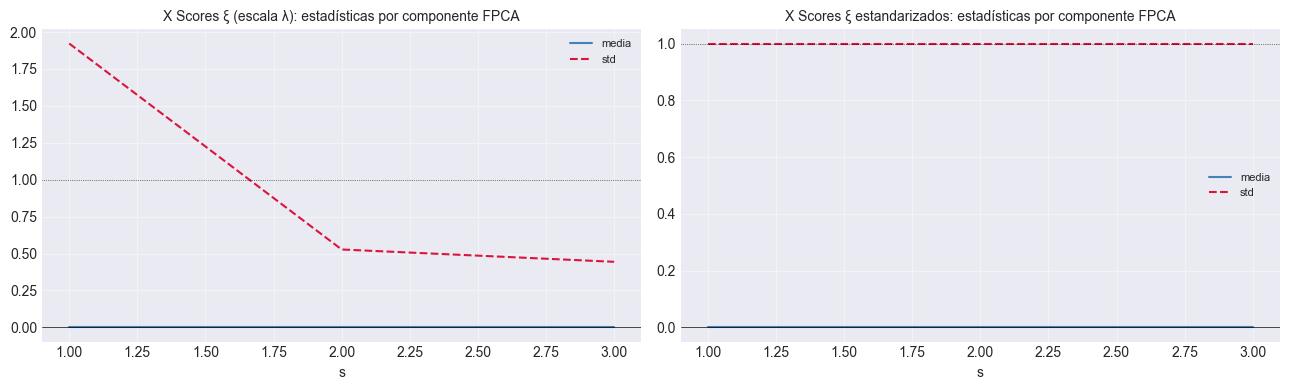

In [20]:
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

_chk = scores_standardizer.verificar_ajuste(T0)
print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
      f"({_chk['etiqueta_ajuste']}) → ok={_chk['ajuste_ok']}")

SCORES_STD       = scores_standardizer.transform(SCORES)
SCORES_STD_train = SCORES_STD[idx_train]
SCORES_STD_test  = SCORES_STD[idx_test]

print(f"\nSCORES_STD {SCORES_STD.shape}")
print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (≈0)")
print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (≈0)")
print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")

guardar_estandarizador(PATHS, scores_standardizer)
_res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                    meta_extra={"T0": int(T0)})
print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

plot_diagnostico_estandarizacion(
    SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
    labels=("Scores ξ (escala λ)", "Scores ξ estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
plt.show()

### 4.2 Diagnóstico de rezagos (sólo train)

A diferencia de la corrida 12, aquí **sí** debe haber dependencia lineal en la
media: los dos operadores son autorregresivos y el mecanismo de régimen
introduce además una dependencia no lineal del nivel rezagado. Los mapas de
calor la muestran; lo que **no** pueden mostrar es que esa dependencia sea una
mezcla de dos regímenes, que es justamente el rasgo del escenario.

Se agrega por eso un panel propio: la correlación de cada score con el
**régimen sorteado**, que cuantifica cuánta de la señal disponible en los
rezagos es señal de régimen.

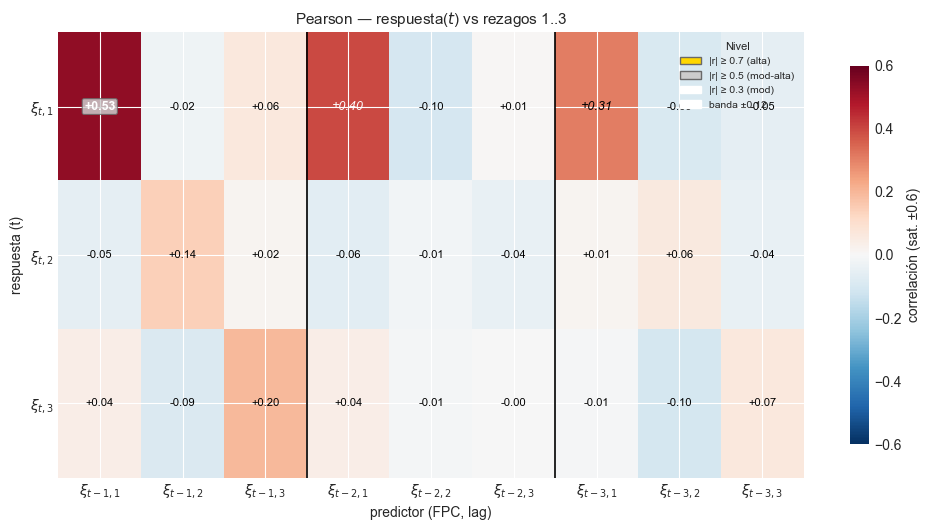

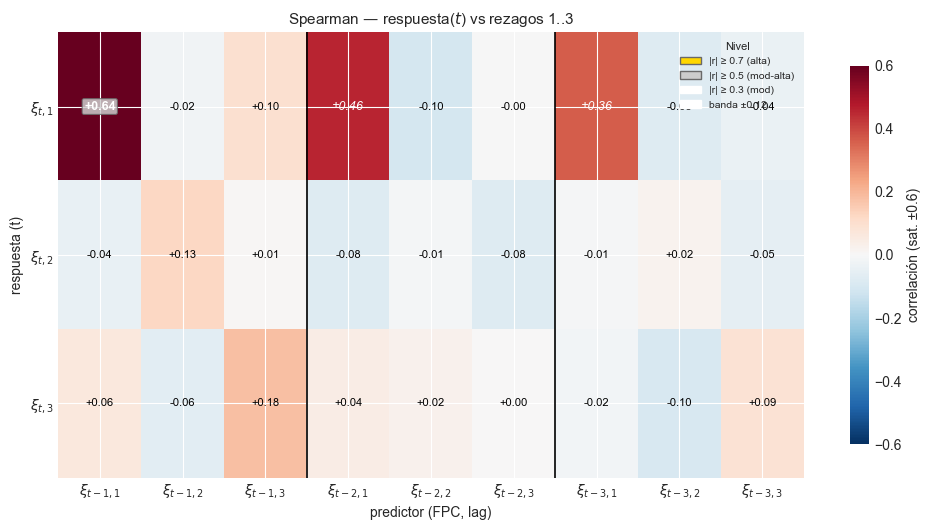

corr(score_t, régimen_t) por componente:
  FPC 1: -0.923  ◄ carga el régimen
  FPC 2: +0.017
  FPC 3: +0.084

máx |corr| en los rezagos (Pearson): 0.533   (banda de ruido 0.118)


In [21]:
N_LAGS_MAX = 3
T_theta, K_total = SCORES_STD_train.shape

def _spearman(Y, Xm):
    """Spearman columna a columna vía rangos (pandas, sin scipy)."""
    Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
    Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
corr_s = np.zeros_like(corr_p)
col_labels = []
y_block = SCORES_STD_train[N_LAGS_MAX:, :]

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
    sp = _spearman(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_s[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band = 1.96 / np.sqrt(len(y_block))

for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
    plot_rezagos_heatmap(
        M_corr, col_labels, row_labels,
        title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}",
        n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
        save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
    plt.show()

# Panel propio del escenario: correlación de cada score con el régimen vigente
corr_reg = np.array([np.corrcoef(SCORES_STD_train[:, k], reg_tr)[0, 1]
                     for k in range(K_total)])
print("corr(score_t, régimen_t) por componente:")
for k in range(K_total):
    marca = "  ◄ carga el régimen" if abs(corr_reg[k]) > 0.4 else ""
    print(f"  FPC {k+1}: {corr_reg[k]:+.3f}{marca}")
print(f"\nmáx |corr| en los rezagos (Pearson): {np.abs(corr_p).max():.3f}   "
      f"(banda de ruido {band:.3f})")

### 4.3 `[CONFIG]` Orden AR y construcción de los datasets

Los rezagos del primer origen de prueba vienen del final del bloque de
entrenamiento: son observaciones pasadas disponibles en cada origen, de modo
que su uso es el condicionamiento de la predicción a $h=1$, no fuga.

`N_LAGS = 1` se mantiene igual que en las corridas 11 y 12, y aquí queda
además justificado por el generador: tanto el operador vigente como la
probabilidad de régimen dependen **sólo** de $X_{t-1}$, de modo que un rezago
contiene toda la información que el mecanismo utiliza.

In [22]:
N_LAGS        = 1
COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

n_components = len(COMPONENT_IDX)
n_train_eff  = T0 - N_LAGS
n_test_eff   = T - T0

assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
             for lag in range(1, N_LAGS + 1)
             for j in range(n_components)]

print(f"componentes : {n_components} → índices {COMPONENT_IDX}")
print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
print(f"cov_names   : {cov_names}")

componentes : 3 → índices [0, 1, 2]
N_LAGS      : 1   ·   p = 3 covariables
n_train_eff : 279   n_test_eff : 120
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']


In [23]:
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

def _dataset_bloque(k, t_ini, t_fin):
    """Respuesta en t ∈ [t_ini, t_fin) y predictores en t-1 … t-N_LAGS."""
    t_idx  = np.arange(t_ini, t_fin)
    X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
    return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                        columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

manifest = {
    "scores_scale":  "standardized_zscore_ddof0",
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
    "ajuste_en": "train",
}
guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
for k in range(n_components):
    print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (279, 4) · test (120, 4)
  fpc_2: train (279, 4) · test (120, 4)
  fpc_3: train (279, 4) · test (120, 4)


## 5. `[CONFIG]` Hiperparámetros y configuración MCMC

Esto es el **contrato con MATLAB**: `psbp_fd_iteracion.m` lee estos valores del
JSON y no los tiene escritos a mano, incluida `seed_base`.

Ojo con la doble acepción de `M`: aquí, dentro de `mcmc_config`, es el tamaño
de la grilla de localización $G^*$ del stick-breaking, **no** el número de
componentes FPCA. `N` es el truncamiento del número de átomos.

Priors y `mcmc_config` **idénticos a los de las corridas 11 y 12**. En este
escenario el prior `E[\pi]=0.90` sobre el propio rezago sí está bien orientado
—hay dependencia autorregresiva genuina—, lo cual conviene recordar al comparar
las PIP entre escenarios: la misma cifra significa cosas distintas según lo
que el generador haya puesto en la media.

In [24]:
MCMC_CONFIG = {"nsim": 2000, "burn": 500, "N": 35, "M": 35}
N_CHAINS    = 3

print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS} cadenas por componente "
      f"→ {N_CHAINS * n_components} jobs en MATLAB")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) × {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")
print(f"\nN = {MCMC_CONFIG['N']} átomos. El generador tiene {J} regímenes, de "
      f"modo que bastarían\nunos pocos átomos; el truncamiento holgado se "
      f"mantiene por comparabilidad con\nlas corridas anteriores y porque la "
      f"ocupación efectiva es un resultado, no un\nsupuesto (ver 13_03 §4).")

MCMC_CONFIG : {'nsim': 2000, 'burn': 500, 'N': 35, 'M': 35}
N_CHAINS    : 3 cadenas por componente → 9 jobs en MATLAB
Draws posteriores por score: (2000 - 500) × 3 = 4500

N = 35 átomos. El generador tiene 2 regímenes, de modo que bastarían
unos pocos átomos; el truncamiento holgado se mantiene por comparabilidad con
las corridas anteriores y porque la ocupación efectiva es un resultado, no un
supuesto (ver 13_03 §4).


In [25]:
# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors por tipo de covariable: (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0, 0.0, 1.0),   # E[pi] = 0.90 — el propio rezago 1
    "cross_lag": (1.0, 1.0, 0.0, 1.0),   # E[pi] = 0.50 — los cruzados
}

def _clasificar(nombre, k_modelo):
    return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
            else "cross_lag")

HYPERPARAMS_LIST = []
for k in range(n_components):
    tipos = [_clasificar(nm, k) for nm in cov_names]
    vals  = np.array([HP_BY_TYPE[t] for t in tipos], dtype=float)   # (p, 4)
    HYPERPARAMS_LIST.append({**HP_GLOBAL,
        "apij": vals[:, 0], "bpij": vals[:, 1],
        "mupsij": vals[:, 2], "taupsij": vals[:, 3]})

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"\nComponente k={k}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'variable':<22} {'tipo':<11} {'apij':>6} {'bpij':>6} {'E[pi]':>7}")
    for j, nm in enumerate(cov_names):
        a, b = hp["apij"][j], hp["bpij"][j]
        marca = "  ◄" if _clasificar(nm, k) == "own_lag1" else ""
        print(f"  {nm:<22} {_clasificar(nm, k):<11} {a:>6.1f} {b:>6.1f} "
              f"{a/(a+b):>7.3f}{marca}")


Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  ◄
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  ◄
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=2  (fpc_3)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             own_lag1       9.0    1.0   0.900  ◄


In [26]:
hp_artifact = {
    "global":       HP_GLOBAL,
    "by_type":      HP_BY_TYPE,
    "mcmc_config":  MCMC_CONFIG,
    "n_iter":       N_CHAINS,
    "seed_scheme":  "seed_base + chain*9973 + k*31",
    "escenario_id": int(ESCENARIO_ID),
    "replica_id":   int(REPLICA_ID),
    "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
    "scores_scale": "standardized_zscore_ddof0",
    "partition": {
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                        for k in range(n_components)],
        "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                        for k in range(n_components)],
    },
    "hyperparams_list": [
        {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
         "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                         for key, v in HYPERPARAMS_LIST[k].items()}}
        for k in range(n_components)
    ],
}
guardar_hiperparametros(PATHS, hp_artifact)
print(f"✓ hyperparameters.json → {PATHS['out_artefact']}")

✓ hyperparameters.json → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_3_r01


## 6. Configuración de evaluación, líneas base y verificación del contrato

`objetivo_evaluacion` y `modo_residuo` se declaran aquí porque cambian el
significado de toda la evaluación y no deben quedar como una decisión implícita
del notebook `_04`.

El bloque `estratificacion` difiere del de la corrida 12 en un punto que
importa: el estado verdadero es **discreto** (el régimen), de modo que
`metodo = "estado discreto"` y no hay cuantilización. `13_04` pasa
`regimen_idx` directo a `cobertura_condicional`.

In [27]:
eval_config = {
    "scheme":      "holdout_temporal",
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "horizons":    [1],
    "n_lags":      int(N_LAGS),
    "scores_scale": "standardized_zscore_ddof0",
    # Contra QUÉ se mide el error y con qué banda:
    #   curva_verdadera + modo_residuo "ninguno" ⇒ la banda cubre la curva
    #   PROYECTADA sobre las M autofunciones y se contrasta con X_t(tau).
    "objetivo_evaluacion": "curva_verdadera",
    "modo_residuo":        "ninguno",
    "nivel_credibilidad":  0.95,
    "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
    "metrics_scores": ["RMSE", "R2", "razon_dispersion"],
    "metrics_curvas": ["MISE", "RMSE_funcional"],
    "metrics_dist":   ["CRPS", "energy_score", "cobertura_95", "PIT"],
    # Eje 2: calibración condicional al estado VERDADERO. Aquí es DISCRETO.
    "estratificacion": {
        "variable":    "regimen_idx",
        "descripcion": "régimen vigente del generador (estado latente, base-0)",
        "fuente":      "reports/.../10_estado_regimen.csv",
        "respaldo":    f"raw/escenario_{ESCENARIO_ID}.npz::interno_regimenes",
        "n_estratos":  int(J),
        "etiquetas":   [f"régimen {j+1}" for j in range(J)],
        "metodo":      "estado discreto del generador, sin cuantilizar",
    },
    # Propio del Algoritmo 3: orígenes con peso de mezcla cercano a 1/2, donde
    # la condicional es genuinamente bimodal y un modelo unimodal no puede
    # seguir. 13_04 §9.1 los usa para examinar la forma de la predictiva.
    "origenes_ambiguos": {
        "variable": "ambiguedad",
        "regla":    "ambiguedad > 0.4  (equivale a |p - 0.5| < 0.1)",
    },
}
guardar_config_evaluacion(PATHS, eval_config)
print("[out_artefact] eval_config.json")
for k, v in eval_config.items():
    print(f"  {k:22s}: {v}")

[out_artefact] eval_config.json
  scheme                : holdout_temporal
  T                     : 400
  T0                    : 280
  prop_train            : 0.7
  horizons              : [1]
  n_lags                : 1
  scores_scale          : standardized_zscore_ddof0
  objetivo_evaluacion   : curva_verdadera
  modo_residuo          : ninguno
  nivel_credibilidad    : 0.95
  ventana_movil         : {'w': [10, 20, 40], 'paso': 1, 'solapadas': True}
  metrics_scores        : ['RMSE', 'R2', 'razon_dispersion']
  metrics_curvas        : ['MISE', 'RMSE_funcional']
  metrics_dist          : ['CRPS', 'energy_score', 'cobertura_95', 'PIT']
  estratificacion       : {'variable': 'regimen_idx', 'descripcion': 'régimen vigente del generador (estado latente, base-0)', 'fuente': 'reports/.../10_estado_regimen.csv', 'respaldo': 'raw/escenario_3.npz::interno_regimenes', 'n_estratos': 2, 'etiquetas': ['régimen 1', 'régimen 2'], 'metodo': 'estado discreto del generador, sin cuantilizar'}
  origen

### 6.1 Líneas base

A diferencia de la corrida 12, aquí las líneas base **sí son un piso exigente
de superar en RMSE**: hay dependencia autorregresiva genuina y la persistencia
recoge parte de ella. La ventaja del PSBPM-FD debería verse en las dos partes:
mejor RMSE —porque la media condicional depende del régimen— y, sobre todo,
mejor CRPS y mejor cobertura condicional, porque ninguna línea base puede
producir una predictiva bimodal.

In [28]:
# Líneas base a h=1: el piso que el PSBP-FD debe superar.
baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                               fpca=fpca, X_obs=X_true, tau=grilla, h=1)
baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
display(baselines_df.style.format("{:.4f}", na_rep="—")
        .set_caption("Líneas base — bloque de prueba, h=1, contra la curva VERDADERA"))

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,120.0000,0.9379,1.0793,1.0170,1.0114,-0.0208,3.8861,1.9713
persistencia_lag1,120.0000,0.8963,1.2631,1.2474,1.1356,-0.2935,3.8078,1.9514


In [29]:
informe = verificar_contrato(PATHS)
print(f"contrato_ok = {informe['contrato_ok']}   "
      f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
      f"n_components={informe['n_components']})")
print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas (T0={informe['T0']})")
print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
if not informe["contrato_ok"]:
    print("\nPROBLEMAS:")
    for p in informe.get("problemas", []):
        print(f"  - {p}")

print(f"\n{'='*66}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"EXPERIMENT_ID = {EXPERIMENT_ID}\n{'='*66}")

contrato_ok = True   (M=3, K=8, T0=280, n_components=3)
estandarizador ajustado con 280 filas (T0=280)
verificación FPCA: todo_ok = True

Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
EXPERIMENT_ID = escenario_3_r01
